In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from bs4 import BeautifulSoup
from urllib.parse import urlparse
sns.set_theme(style="whitegrid")

In [3]:
url = "https://inet.detik.com/indeks"

In [4]:
response = requests.get(url,headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
response.raise_for_status()
soup = BeautifulSoup(response.text, "html.parser")
berita = soup.select("a[dtr-ttl][i-info]")

print("Jumlah Berita:", len(berita))
print("Jumlah Berita:", berita[0]["dtr-ttl"])

Jumlah Berita: 20
Jumlah Berita: BMKG Luruskan Screenshot Komentar soal Anak Krakatau yang Ramai Dibahas


In [9]:
data = []
id_tersimpan = set()

for halaman in range(1, 121):
    response = requests.get(
        "https://inet.detik.com/indeks",
        params={"page": halaman},
        headers={"User-Agent": "DM-PracticeBot/1.0"},
        timeout=30
    )
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    for berita in soup.select("a[dtr-ttl][i-info]"):
        link = berita.get("href", "")
        id_berita = berita.get("dtr-id")

        if urlparse(link).netloc != "inet.detik.com":
            continue

        if not id_berita or id_berita in id_tersimpan:
            continue

        info = BeautifulSoup(berita["i-info"], "html.parser")
        waktu = info.find("span")

        data.append({
            "id_berita": id_berita,
            "judul": berita.get("dtr-ttl"),
            "kategori": urlparse(link).path.strip("/").split("/")[0],
            "timestamp": waktu.get("d-time") if waktu else None,
            "waktu_teks": waktu.get("title") if waktu else None,
            "url": link,
            "gambar": berita.get("i-img")
        })

        id_tersimpan.add(id_berita)

    pd.DataFrame(data).to_csv("berita_raw.csv", index=False)
    print(f"Halaman {halaman}: {len(data)} berita unik")

    if len(data) >= 1600:
        break

    time.sleep(2)

assert len(data) >= 1500, "Hasil belum memenuhi minimal 1.500 baris."

Halaman 1: 20 berita unik
Halaman 2: 40 berita unik
Halaman 3: 60 berita unik
Halaman 4: 80 berita unik
Halaman 5: 100 berita unik
Halaman 6: 119 berita unik
Halaman 7: 139 berita unik
Halaman 8: 159 berita unik
Halaman 9: 179 berita unik
Halaman 10: 198 berita unik
Halaman 11: 218 berita unik
Halaman 12: 238 berita unik
Halaman 13: 257 berita unik
Halaman 14: 277 berita unik
Halaman 15: 297 berita unik
Halaman 16: 317 berita unik
Halaman 17: 337 berita unik
Halaman 18: 357 berita unik
Halaman 19: 377 berita unik
Halaman 20: 397 berita unik
Halaman 21: 417 berita unik
Halaman 22: 437 berita unik
Halaman 23: 457 berita unik
Halaman 24: 477 berita unik
Halaman 25: 497 berita unik
Halaman 26: 517 berita unik
Halaman 27: 537 berita unik
Halaman 28: 556 berita unik
Halaman 29: 576 berita unik
Halaman 30: 596 berita unik
Halaman 31: 616 berita unik
Halaman 32: 636 berita unik
Halaman 33: 655 berita unik
Halaman 34: 675 berita unik
Halaman 35: 695 berita unik
Halaman 36: 715 berita unik
Halam

In [11]:
#Load Dataset
df = pd.read_csv("berita_raw.csv", dtype={"id_berita": str})
display(df.head())
print(df.shape)
df.info()
display(df.dtypes)

,id_berita,judul,kategori,timestamp,waktu_teks,url,gambar
0,8658510,Deretan Material Mewah yang Pernah Dipakai di ...,consumer,1789117601,"Jumat, 11 Sep 2026 16:06 WIB",https://inet.detik.com/consumer/d-8658510/dere...,https://awsimages.detik.net.id/community/media...
1,8658626,BMKG Luruskan Screenshot Komentar soal Anak Kr...,science,1789115963,"Jumat, 11 Sep 2026 15:39 WIB",https://inet.detik.com/science/d-8658626/bmkg-...,https://awsimages.detik.net.id/community/media...
2,8658435,Angka Pengguna Apple yang Beralih ke HP Lipat ...,consumer,1789114112,"Jumat, 11 Sep 2026 15:08 WIB",https://inet.detik.com/consumer/d-8658435/angk...,https://awsimages.detik.net.id/community/media...
3,8658417,"Viral Tren Foto 80an Pakai ChatGPT, Diam-diam ...",science,1789111835,"Jumat, 11 Sep 2026 14:30 WIB",https://inet.detik.com/science/d-8658417/viral...,https://awsimages.detik.net.id/community/media...
4,8658451,7 Alasan ASUS Vivobook Go 14 (E1404FA) Cocok J...,consumer,1789111640,"Jumat, 11 Sep 2026 14:27 WIB",https://inet.detik.com/consumer/d-8658451/7-al...,https://awsimages.detik.net.id/community/media...


(1611, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1611 entries, 0 to 1610
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_berita   1611 non-null   object
 1   judul       1611 non-null   object
 2   kategori    1611 non-null   object
 3   timestamp   1611 non-null   int64 
 4   waktu_teks  1611 non-null   object
 5   url         1611 non-null   object
 6   gambar      1610 non-null   object
dtypes: int64(1), object(6)
memory usage: 88.2+ KB


,0
id_berita,object
judul,object
kategori,object
timestamp,int64
waktu_teks,object
url,object
gambar,object


In [14]:
#Cek Missing Value
display(pd.DataFrame({
    "Jumlah kosong": df.isna().sum(),"Persentase": (df.isna().mean() * 100).round(2)}))
print("Duplicate:", df.duplicated().sum())
print("Duplicate ID:", df["id_berita"].duplicated().sum())

,Jumlah kosong,Persentase
id_berita,0,0.00
judul,0,0.00
kategori,0,0.00
timestamp,0,0.00
waktu_teks,0,0.00
url,0,0.00
gambar,1,0.06


Duplicate: 0
Duplicate ID: 0


In [16]:
df = df.drop_duplicates(subset="id_berita").copy()
df["judul"] = df["judul"].str.strip()
df["judul"] = df["judul"].replace("", pd.NA)
df["tanggal"] = pd.to_datetime(pd.to_numeric(df["timestamp"], errors="coerce"),unit="s", utc=True, errors="coerce").dt.tz_convert("Asia/Jakarta")
df["jam"] = df["tanggal"].dt.hour
df["jumlah_kata"] = df["judul"].str.split().str.len()
df["jumlah_karakter"] = df["judul"].str.len()

display(df.head())
print("Berita Unik:", len(df))


,id_berita,judul,kategori,timestamp,waktu_teks,url,gambar,tanggal,jam,jumlah_kata,jumlah_karakter
0,8658510,Deretan Material Mewah yang Pernah Dipakai di ...,consumer,1789117601,"Jumat, 11 Sep 2026 16:06 WIB",https://inet.detik.com/consumer/d-8658510/dere...,https://awsimages.detik.net.id/community/media...,2026-09-11 16:06:41+07:00,16,9,57
1,8658626,BMKG Luruskan Screenshot Komentar soal Anak Kr...,science,1789115963,"Jumat, 11 Sep 2026 15:39 WIB",https://inet.detik.com/science/d-8658626/bmkg-...,https://awsimages.detik.net.id/community/media...,2026-09-11 15:39:23+07:00,15,10,71
2,8658435,Angka Pengguna Apple yang Beralih ke HP Lipat ...,consumer,1789114112,"Jumat, 11 Sep 2026 15:08 WIB",https://inet.detik.com/consumer/d-8658435/angk...,https://awsimages.detik.net.id/community/media...,2026-09-11 15:08:32+07:00,15,10,62
3,8658417,"Viral Tren Foto 80an Pakai ChatGPT, Diam-diam ...",science,1789111835,"Jumat, 11 Sep 2026 14:30 WIB",https://inet.detik.com/science/d-8658417/viral...,https://awsimages.detik.net.id/community/media...,2026-09-11 14:30:35+07:00,14,11,68
4,8658451,7 Alasan ASUS Vivobook Go 14 (E1404FA) Cocok J...,consumer,1789111640,"Jumat, 11 Sep 2026 14:27 WIB",https://inet.detik.com/consumer/d-8658451/7-al...,https://awsimages.detik.net.id/community/media...,2026-09-11 14:27:20+07:00,14,12,69


Berita Unik: 1611


In [17]:
kolom_numerik = ["jumlah_kata", "jumlah_karakter"]
display(df[kolom_numerik].describe().round(2))
print("Median:")
display(df[kolom_numerik].median())
print("Modus:")
display(df[kolom_numerik].mode())

,jumlah_kata,jumlah_karakter
count,1611.00,1611.00
mean,9.93,62.52
std,1.63,8.40
min,3.00,18.00
25%,9.00,57.00
50%,10.00,63.00
75%,11.00,68.00
max,16.00,84.00


Median:


,0
jumlah_kata,10.0
jumlah_karakter,63.0


Modus:


,jumlah_kata,jumlah_karakter
0,9,64


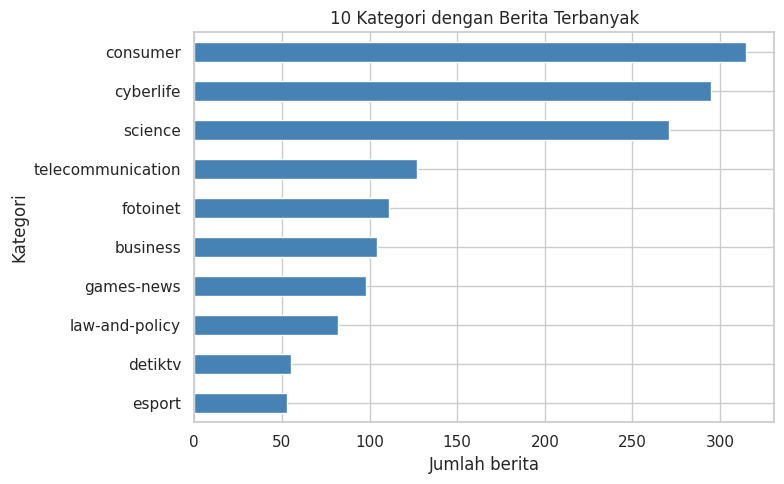

In [19]:
df["kategori"].value_counts().head(10).plot(kind="barh", figsize=(8, 5), color="steelblue")
plt.title("10 Kategori dengan Berita Terbanyak")
plt.xlabel("Jumlah berita")
plt.ylabel("Kategori")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

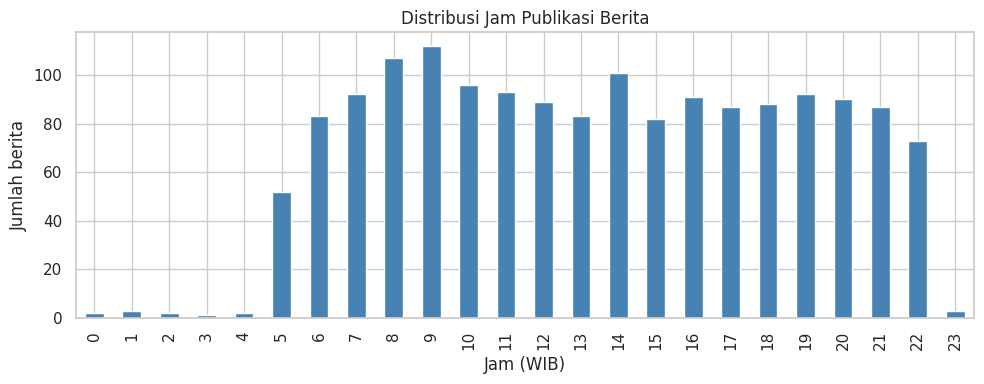

In [21]:
df["jam"].value_counts().reindex(range(24), fill_value=0).plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.title("Distribusi Jam Publikasi Berita")
plt.xlabel("Jam (WIB)")
plt.ylabel("Jumlah berita")
plt.tight_layout()
plt.show()

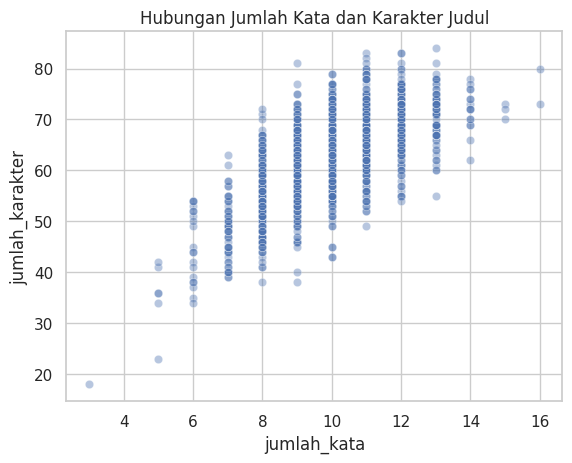

Korelasi Pearson: 0.68


In [22]:
sns.scatterplot(
    data=df,
    x="jumlah_kata",
    y="jumlah_karakter",
    alpha=0.4
)

plt.title("Hubungan Jumlah Kata dan Karakter Judul")
plt.show()

print(
    "Korelasi Pearson:",
    round(df["jumlah_kata"].corr(df["jumlah_karakter"]), 2)
)

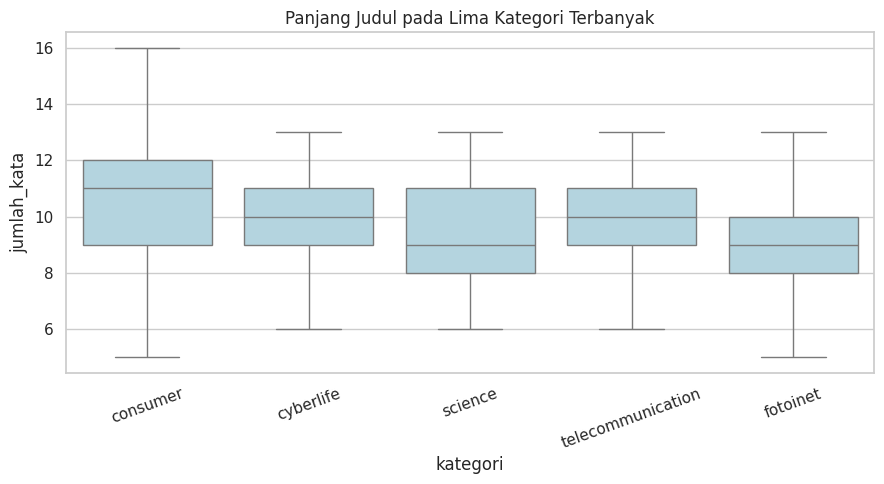

,count,median
kategori,,
consumer,315,11.0
cyberlife,295,10.0
science,271,9.0
telecommunication,127,10.0
fotoinet,111,9.0


In [23]:
kategori_utama = df["kategori"].value_counts().head(5).index

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df[df["kategori"].isin(kategori_utama)],
    x="kategori",
    y="jumlah_kata",
    order=kategori_utama,
    color="lightblue"
)

plt.title("Panjang Judul pada Lima Kategori Terbanyak")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(
    df.groupby("kategori")["jumlah_kata"]
    .agg(["count", "median"])
    .loc[kategori_utama]
)

In [24]:
df.to_csv("berita_clean.csv", index=False)

print("Jumlah baris:", len(df))
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 1611
Jumlah kolom: 11
